In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pulp

print("Libraries imported successfully. PuLP version:", pulp.__version__)

Libraries imported successfully. PuLP version: 3.3.2


In [12]:
# تنظیم بذر تصادفی برای تکرارپذیری نتایج
np.random.seed(42)

# ۱. پله‌های عرضه نیروگاهی (ظرفیت مگاوات و هزینه نهایی تولید یورو بر مگاوات ساعت)
num_gens = 12
gen_capacities = np.random.uniform(50, 250, num_gens)
gen_costs = np.sort(
    np.random.uniform(15, 110, num_gens)
)  # مرتب‌سازی صعودی هزینه‌ها

supply_bids = pd.DataFrame(
    {
        "Gen_ID": [f"G_{i+1}" for i in range(num_gens)],
        "Capacity_MW": gen_capacities,
        "Marginal_Cost": gen_costs,
    }
)

# ۲. پله‌های تقاضای بازار (حجم و تمایل به پرداخت)
num_demands = 10
dem_volumes = np.random.uniform(40, 200, num_demands)
dem_values = np.sort(np.random.uniform(50, 130, num_demands))[
    ::-1
]  # مرتب‌سازی نزولی مطلوبیت

demand_bids = pd.DataFrame(
    {
        "Demand_ID": [f"D_{j+1}" for j in range(num_demands)],
        "Volume_MW": dem_volumes,
        "Willingness_to_Pay": dem_values,
    }
)

print("--- Supply Bids Sample ---")
display(supply_bids.head(3))
print("--- Demand Bids Sample ---")
display(demand_bids.head(3))

--- Supply Bids Sample ---


,Gen_ID,Capacity_MW,Marginal_Cost
0,G_1,124.908024,28.251917
1,G_2,240.142861,32.273372
2,G_3,196.398788,32.423428


--- Demand Bids Sample ---


,Demand_ID,Volume_MW,Willingness_to_Pay
0,D_1,112.971197,127.250563
1,D_2,165.628154,122.745632
2,D_3,71.947805,114.671788


In [13]:
# تعریف مسئله بهینه‌سازی پاکسازی بازار (Social Welfare Maximization)
market_model = pulp.LpProblem("Day_Ahead_Market_Clearing", pulp.LpMaximize)

# متغیرهای تصمیم برای تولید و مصرف
p_gen = {
    i: pulp.LpVariable(
        f"Gen_{i}",
        lowBound=0,
        upBound=supply_bids.loc[i, "Capacity_MW"],
        cat="Continuous",
    )
    for i in supply_bids.index
}

p_dem = {
    j: pulp.LpVariable(
        f"Dem_{j}",
        lowBound=0,
        upBound=demand_bids.loc[j, "Volume_MW"],
        cat="Continuous",
    )
    for j in demand_bids.index
}

# تابع هدف: بیشینه‌سازی رفاه اجتماعی (مطلوبیت تقاضا منهای هزینه‌های تولید)
social_welfare = pulp.lpSum(
    p_dem[j] * demand_bids.loc[j, "Willingness_to_Pay"] for j in demand_bids.index
) - pulp.lpSum(
    p_gen[i] * supply_bids.loc[i, "Marginal_Cost"] for i in supply_bids.index
)

market_model += social_welfare

# محدودیت تعادل بازار: توازن کل تولید و کل مصرف
market_model += (
    pulp.lpSum(p_gen[i] for i in supply_bids.index)
    == pulp.lpSum(p_dem[j] for j in demand_bids.index),
    "Market_Balance",
)

# حل مدل با سالور CBC
market_model.solve(pulp.PULP_CBC_CMD(msg=0))

print("Optimization Status:", pulp.LpStatus[market_model.status])
print(
    "Total Optimized Social Welfare: €"
    f"{pulp.value(market_model.objective):,.2f}"
)

Optimization Status: Optimal
Total Optimized Social Welfare: €58,584.27


Market Clearing Price (MCP): -49.80 €/MWh


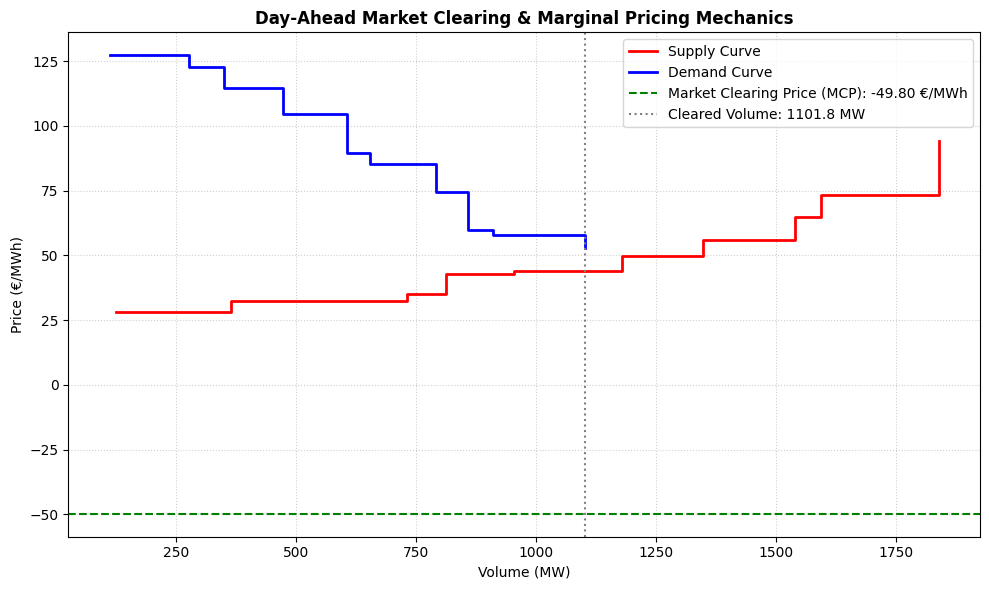

Outputs successfully saved in 'outputs/' directory.


In [14]:
# استخراج قیمت حاشیه‌ای بازار (Market Clearing Price) از قیمت سایه‌ای (Dual Price) محدودیت تعادل
mcp = market_model.constraints["Market_Balance"].pi
print(f"Market Clearing Price (MCP): {mcp:.2f} €/MWh")

# ثبت حجم‌های پذیرفته‌شده
supply_bids["Cleared_Volume_MW"] = [pulp.value(p_gen[i]) for i in supply_bids.index]
demand_bids["Cleared_Volume_MW"] = [pulp.value(p_dem[j]) for j in demand_bids.index]

# ذخیره‌سازی جداول در پوشه outputs
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

supply_bids.to_csv(
    os.path.join(output_dir, "market_clearing_supply.csv"), index=False
)
demand_bids.to_csv(
    os.path.join(output_dir, "market_clearing_demand.csv"), index=False
)

# رسم منحنی تعادل عرضه و تقاضا
plt.figure(figsize=(10, 6))
sorted_supply = supply_bids.sort_values("Marginal_Cost").reset_index(drop=True)
sorted_supply["Cumulative_Capacity"] = sorted_supply["Capacity_MW"].cumsum()

sorted_demand = demand_bids.sort_values(
    "Willingness_to_Pay", ascending=False
).reset_index(drop=True)
sorted_demand["Cumulative_Volume"] = sorted_demand["Volume_MW"].cumsum()

plt.step(
    sorted_supply["Cumulative_Capacity"],
    sorted_supply["Marginal_Cost"],
    where="post",
    label="Supply Curve",
    color="red",
    linewidth=2,
)
plt.step(
    sorted_demand["Cumulative_Volume"],
    sorted_demand["Willingness_to_Pay"],
    where="post",
    label="Demand Curve",
    color="blue",
    linewidth=2,
)

total_cleared_vol = supply_bids["Cleared_Volume_MW"].sum()
plt.axhline(
    y=mcp,
    color="green",
    linestyle="--",
    label=f"Market Clearing Price (MCP): {mcp:.2f} €/MWh",
)
plt.axvline(
    x=total_cleared_vol,
    color="gray",
    linestyle=":",
    label=f"Cleared Volume: {total_cleared_vol:.1f} MW",
)

plt.title(
    "Day-Ahead Market Clearing & Marginal Pricing Mechanics",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Volume (MW)", fontsize=10)
plt.ylabel("Price (€/MWh)", fontsize=10)
plt.legend(loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

chart_path = os.path.join(output_dir, "market_clearing_dynamics.png")
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"Outputs successfully saved in '{output_dir}/' directory.")